In [1]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. KLASÖR DÜZENLEME (Otomatik Ayrıştırma)
# ==========================================
# Karmaşık haldeki veri setini okuyup, dosya isimlerindeki etiketlere göre 
# sınıflara ait alt klasörlere (cloudy, rain, vb.) otomatik olarak dağıtır.
source_dir = r'C:\Users\alien\archive\dataset2\dataset2'
target_base_dir = r'C:\Users\alien\archive\dataset_Duzenli'
classes = ['cloudy', 'rain', 'shine', 'sunrise']

if not os.path.exists(target_base_dir):
    os.makedirs(target_base_dir, exist_ok=True)
    print("Resimler sınıflarına göre ayrıştırılıyor...")
    for filename in os.listdir(source_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            for cls in classes:
                if filename.lower().startswith(cls):
                    class_dir = os.path.join(target_base_dir, cls)
                    os.makedirs(class_dir, exist_ok=True)
                    shutil.copy2(os.path.join(source_dir, filename), os.path.join(class_dir, filename))
                    break
    print(f"İşlem tamam! Düzenli verileriniz şu klasörde: {target_base_dir}\n")
else:
    print("Düzenli klasör zaten mevcut, ayrıştırma adımı atlanıyor.\n")

# ==========================================
# 2. VERİ YÜKLEME VE ÖN İŞLEME
# ==========================================
data_dir = target_base_dir
batch_size = 32
img_height = 128
img_width = 128
# Görüntüleri %80 Eğitim (Training) seti olarak ayırır
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=(img_height, img_width), batch_size=batch_size)
# Görüntüleri %20 Doğrulama (Validation) seti olarak ayırır
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=(img_height, img_width), batch_size=batch_size)

class_names = train_ds.class_names
print(f"\nSınıflar: {class_names}\n")
# Bellek darboğazını (I/O Bottleneck) önlemek için veriler önbelleğe alınır (cache)
# ve eğitim sırasında GPU'yu bekletmemek için prefetch ile optimize edilir.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. MODEL TASARIMI (Optimize Edilmiş CNN)
# ==========================================
num_classes = len(class_names)

model = models.Sequential([
    # Piksel değerlerini [0, 255] aralığından [0, 1] aralığına normalize eder
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    # Görüntüden kenar ve şekil gibi uzamsal özellikleri çıkaran Evrişim (Conv2D) katmanları
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(), # Özellik matrisinin boyutunu küçülterek hesaplama yükünü azaltır
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Çok boyutlu matrisi tek boyutlu vektöre düzleştirir
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    
    # Ağırlıkların rastgele %50'sini kapatarak modelin veriyi ezberlemesini (Overfitting) engeller
    layers.Dropout(0.5), # OVERFITTING'İ ÖNLEMEK İÇİN
    # 4 sınıf için olasılık dağılımı üreten çıktı katmanı (softmax)
    layers.Dense(num_classes, activation='softmax') 
])

Düzenli klasör zaten mevcut, ayrıştırma adımı atlanıyor.

Found 1126 files belonging to 4 classes.
Using 901 files for training.
Found 1126 files belonging to 4 classes.
Using 225 files for validation.

Sınıflar: ['cloudy', 'rain', 'shine', 'sunrise']



C:\Users\alien\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [2]:
# Modelin derlenmesi: Adam optimizatörü ve çok sınıflı logaritmik kayıp fonksiyonu kullanılmıştır
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. EĞİTİM (Early Stopping ile)
# ==========================================
# val_loss değeri 3 epoch boyunca iyileşmezse eğitimi durdurur ve en iyi ağırlıkları geri yükler
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

epochs = 15 
print("Model eğitimi başlıyor...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop]
)

Model eğitimi başlıyor...
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.5760 - loss: 0.9313 - val_accuracy: 0.7333 - val_loss: 0.7577
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7381 - loss: 0.6516 - val_accuracy: 0.7556 - val_loss: 0.6832
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8069 - loss: 0.5187 - val_accuracy: 0.7600 - val_loss: 0.6767
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8357 - loss: 0.4474 - val_accuracy: 0.8133 - val_loss: 0.5691
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8735 - loss: 0.3597 - val_accuracy: 0.8044 - val_loss: 0.6276
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8824 - loss: 0.3499 - val_accuracy: 0.8267 - val_loss: 0.5258
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9101 - loss: 0.2636 - val_accuracy: 0.8356 - val_loss: 0.5836
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9090 - loss: 0.2344 


Sonuçlar hesaplanıyor ve grafikler çiziliyor...


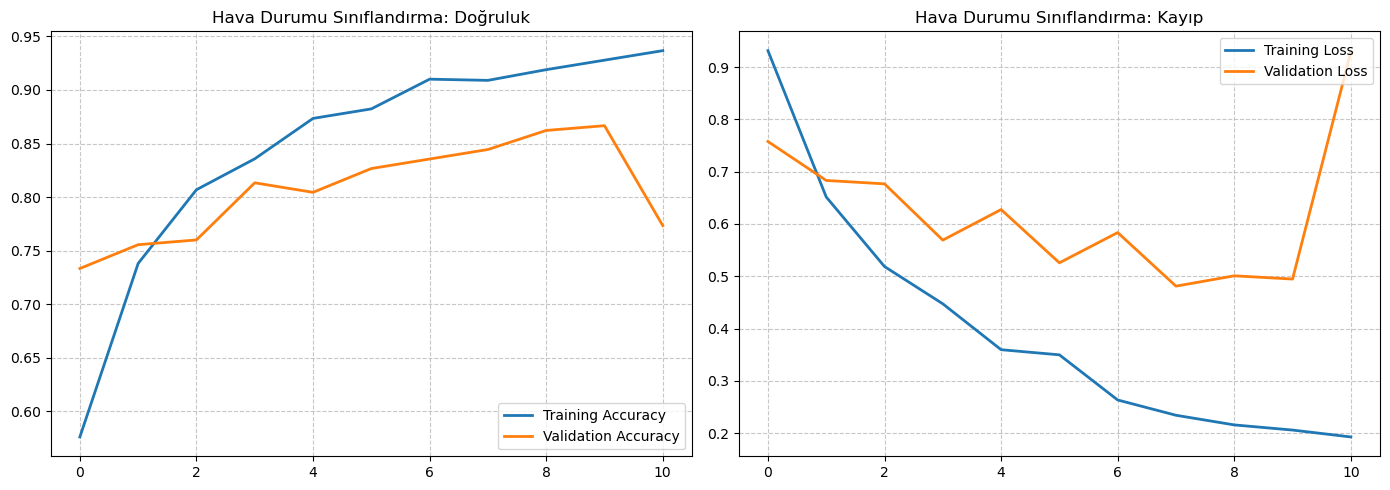


Doğrulama veri setinden tahminler alınıyor...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


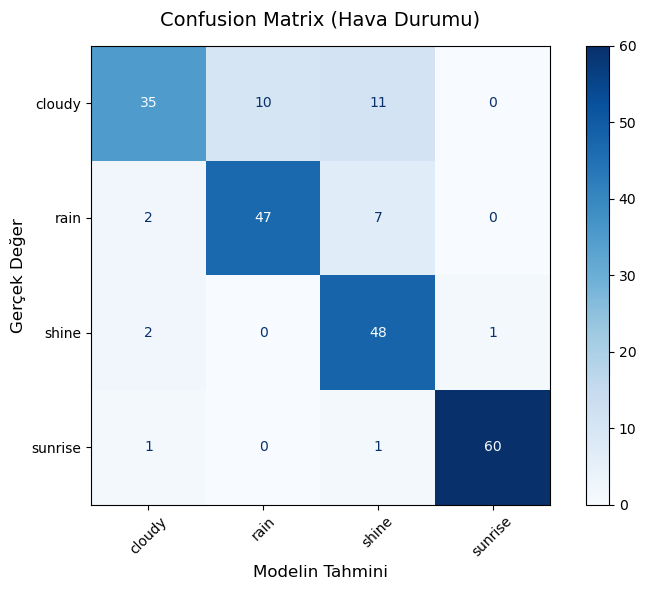


--- SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

      cloudy       0.88      0.62      0.73        56
        rain       0.82      0.84      0.83        56
       shine       0.72      0.94      0.81        51
     sunrise       0.98      0.97      0.98        62

    accuracy                           0.84       225
   macro avg       0.85      0.84      0.84       225
weighted avg       0.86      0.84      0.84       225



In [8]:
# ==========================================
# 5. GRAFİKLER VE METRİKLER (Rapor Beklentileri)
# ==========================================
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

print("\nSonuçlar hesaplanıyor ve grafikler çiziliyor...")

# --- A. Eğitim ve Doğrulama Grafikleri (Accuracy ve Loss) ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
actual_epochs = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(actual_epochs, acc, label='Training Accuracy', linewidth=2)
plt.plot(actual_epochs, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Hava Durumu Sınıflandırma: Doğruluk')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(actual_epochs, loss, label='Training Loss', linewidth=2)
plt.plot(actual_epochs, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Hava Durumu Sınıflandırma: Kayıp')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# B. TAHMİNLERİN (PREDICTION) ALINMASI
# ==========================================
print("\nDoğrulama veri setinden tahminler alınıyor...")

x_val = []
y_true = []

# KRİTİK ÇÖZÜM NOKTASI:
# Veri seti üzerinde SADECE BİR KERE (tek for döngüsü) dönüyoruz.
# Böylece X (resim) ve Y (etiket) eşleşmesi asla bozulmuyor!
for x, y in val_ds:
    x_val.append(x.numpy())
    y_true.append(y.numpy())

x_val = np.concatenate(x_val, axis=0)
y_true = np.concatenate(y_true, axis=0)

# Tahmini x_val üzerinden alıyoruz
y_pred_probs = model.predict(x_val, verbose=1) 
y_pred = np.argmax(y_pred_probs, axis=1)


# --- C. Confusion Matrix (Karmaşa Matrisi) ---
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))

# values_format='d' parametresi sayesinde sayılar eksiksiz ve tam sayı olarak yazılır
disp.plot(cmap='Blues', ax=ax, values_format='d') 

plt.title('Confusion Matrix (Hava Durumu)', pad=15, fontsize=14)
plt.xlabel('Modelin Tahmini', fontsize=12)
plt.ylabel('Gerçek Değer', fontsize=12)
plt.xticks(rotation=45) # Eksen yazılarının birbirine girmemesi için 45 derece döndürüyoruz
plt.tight_layout()
plt.show()


# --- D. Precision, Recall ve F1-Score ---
print("\n--- SINIFLANDIRMA RAPORU ---")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


--- PREDICTION ÖRNEKLERİ ---


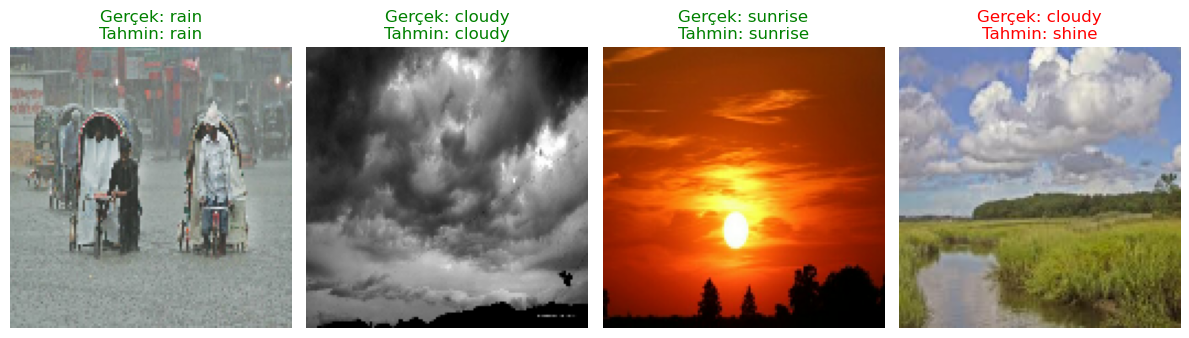

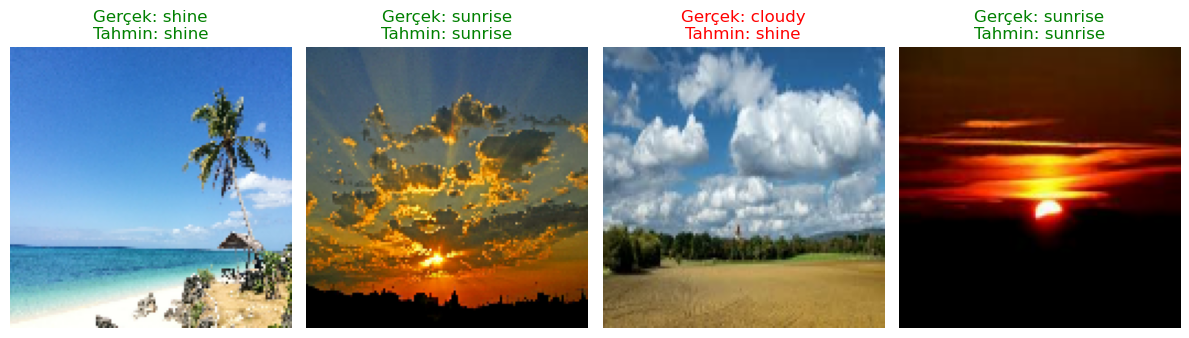

In [9]:
print("\n--- PREDICTION ÖRNEKLERİ ---")
plt.figure(figsize=(12, 4))
indices = np.random.choice(len(x_val), 4, replace=False)

for i, idx in enumerate(indices):
    ax = plt.subplot(1, 4, i + 1)
    plt.imshow(x_val[idx].astype("uint8"))
    
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    
    color = "green" if true_label == pred_label else "red"
    plt.title(f"Gerçek: {true_label}\nTahmin: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()
# --- D. Prediction Örnekleri (Doğru ve Hatalı Seçimler) ---
plt.figure(figsize=(12, 4))

# Doğru ve yanlış tahmin edilen resimlerin indekslerini bulalım
correct_idx = np.where(y_true == y_pred)[0]
wrong_idx = np.where(y_true != y_pred)[0]

# Listeleri karıştıralım
np.random.shuffle(correct_idx)
np.random.shuffle(wrong_idx)

# Ekrana basmak için 3 doğru, 1 yanlış örnek seçelim (Eğer model hiç yanlış yapmadıysa 4 doğru seçer)
selected_indices = []
if len(wrong_idx) > 0:
    selected_indices = list(correct_idx[:3]) + list(wrong_idx[:1])
else:
    selected_indices = list(correct_idx[:4])

# Seçtiğimiz bu 4 resmi de kendi içinde rastgele sıralayalım
np.random.shuffle(selected_indices)

for i, idx in enumerate(selected_indices):
    ax = plt.subplot(1, 4, i + 1)
    plt.imshow(x_val[idx].astype("uint8"))
    
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    
    color = "green" if true_label == pred_label else "red"
    plt.title(f"Gerçek: {true_label}\nTahmin: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

https://www.kaggle.com/datasets/orvile/weather-dataset-for-image-classification